In [1]:
# Importet
import numpy as np
import pandas as pd

# Utforskning av datasets #


In [2]:

# Hämta datan från npz filen - allow 
sequence = np.load('data/segment_sequences.npz', allow_pickle=True)

# Se vad som finns i filen
print(sequence.files)


['X_seq', 'y_seq', 'groups', 'segment_id']


In [3]:
# Läs in csv-filen features för att utforska. 
df_features = pd.read_csv('data/segment_features.csv', sep=None, engine='python')

# Visa de första raderna så man får en överblick
df_features.head()
print()

# Vi kollar hur klassfördelningen ser ut. (mode)
# Är något transportmedel överrepresenterat?
print("Fördelning av transportmedelel")
print(df_features['mode'].value_counts())
print()

# I procent
print("Fördelning i %")
print(df_features['mode'].value_counts(normalize=True) * 100)
print()
print("Kort reflektion:")
print("walk är väldigt överrepresenterat med ca 48 %, car lägst med ca 16 %")
print("walk kommer ev väga för tungt i modellträningen.")


Fördelning av transportmedelel
mode
walk    5412
bus     2298
bike    1859
car     1757
Name: count, dtype: int64

Fördelning i %
mode
walk    47.783860
bus     20.289599
bike    16.413562
car     15.512979
Name: proportion, dtype: float64

Kort reflektion:
walk är väldigt överrepresenterat med ca 48 %, car lägst med ca 16 %
walk kommer ev väga för tungt i modellträningen.


In [4]:
# Läs in csv-filen metadata för att utforska. 
df_metadata = pd.read_csv('data/segment_metadata.csv', sep=None, engine='python')

# Visa de första raderna så man får en överblick
df_metadata.head()

,segment_id,user_id,file_name,mode
0,0,10,20080331160008.plt,car
1,1,10,20080331160008.plt,car
2,2,10,20080402060926.plt,walk
3,3,10,20080402060926.plt,car
4,4,10,20080402060926.plt,bus


### Kommentar ###

**.npz filen:**  Vet inte om vi behöver den? Vet inte riktigt hur man ska göra med den datan eller hur man använder den?

**feature filen:** Här har vi all data vi behöver. features, targets(mode) och ev all userId:s och segmentsID:s.

**metadata filen:** Här har vi samma data som i featuredatan förutom alla features. Vi behöver kanske inte denna fil heller?

**Klassfördelningen:** Är lite skev, walk väger nog lite för tungt i datasetet mot de andra transportmedlen. Vi behöver nog ta hänsyn till det när vi splittar datan sen. Får fundera på hur vi ska lösa det.



# Task 1: Feature engineering and Machine Learning Model #


### Korrrelationsanalys ###

Targets i siffror:
{0: 'bike', 1: 'bus', 2: 'car', 3: 'walk'}


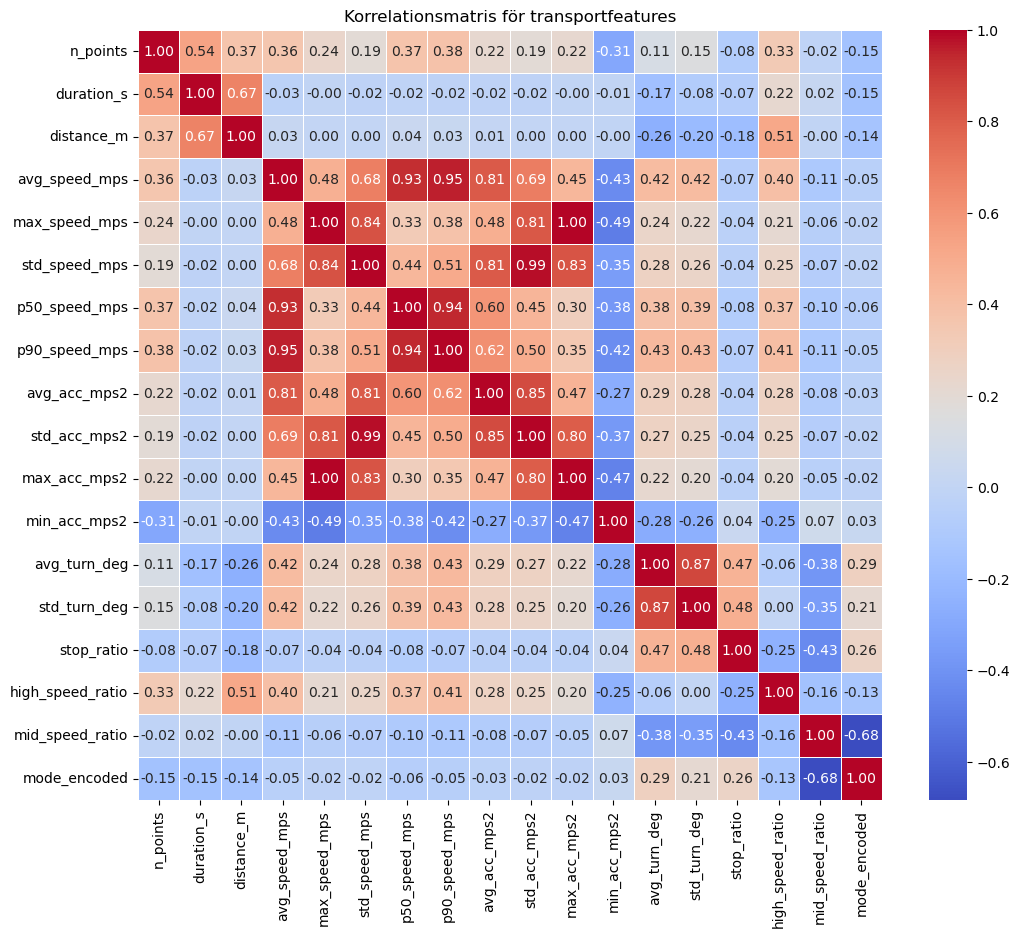


Kommentar: Vi ser tydligt att fart featuresena korrelerar högt, över 93 %. Så där har vi redundans och kan slå ihop eller tar bort nån feature
mid_speed_ratio som ser ut som att det är någon medelelåg hastighetsfeature i filen har ett ganska starkt negativtsamband med målvariabeln (mode_encoded) vilket gör att den tydligt signalerar skillnaden mellan långsamma och sanbbare rörelser. gång - bil tex 


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vi gör först en korrealtionsanalys av alla features för att se vilka som verkar vara relevanta, och
# om vi hittar redundans. Gör det enklare att välja/göra nya features.

# Va tar bort kolumneran segement, id och filnamn då dessa inte är features. 
df_features_test = df_features.drop(columns=['segment_id', 'user_id', 'file_name'])
# Sen behöver vi konvertera mode (target) till siffror.
df_features_test['mode_encoded'] = df_features_test['mode'].astype('category').cat.codes
# kollar vilka siffro alla targets fick
print("Targets i siffror:")
print(dict(enumerate(df_features_test['mode'].astype('category').cat.categories)))
# tar bort gamla mode kolumnen för att kunna räkna. Den är ju en string
df_features_corr = df_features_test.drop(columns='mode')
# Räkna ut korrealtion
corr_matrix = df_features_corr.corr()

# Ritar upp en heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korrelationsmatris för transportfeatures')
plt.show()
print()
print("Kommentar: Vi ser tydligt att fart featuresena korrelerar högt, över 93 %. Så där har vi redundans och kan slå ihop eller tar bort nån feature")
print("mid_speed_ratio som ser ut som att det är någon medelelåg hastighetsfeature i filen har ett ganska starkt negativt" \
"samband med målvariabeln (mode_encoded) vilket gör att den tydligt signalerar skillnaden mellan långsamma och sanbbare rörelser. " \
"gång - bil tex ") 


### Feature engineering ###

In [6]:
# Väljer ut de features vi vill ha med, baserat på exempel från instruktion 
# Skapar en ny datafram för nya/valda features
df_final = pd.DataFrame()
# target/målvariabel
df_final['mode'] = df_features['mode']

# Speed - Använder bara avg för det hade hög korr mot de andra "speed" featuresena. Så vi undviker redundans
df_final['Speed'] = df_features['avg_speed_mps']

# Mellanfart - Läggs till för att det hade högt negativt samband med målvariabel från korr matrisen. Så är troligtvis bra att ha med.
df_final['Mellanfart'] = df_features['mid_speed_ratio']

# Acceleration väljer ut max bara för tror det ger mest. Bör ju kunna skilja på gång och bil tydligt t ex- 
df_final['Max accelaration'] = df_features['max_acc_mps2']

# Distance
df_final['Distance'] = df_features['distance_m']

# Turning angle
df_final['Turning angle'] = df_features['avg_turn_deg']

# Stop ratio
df_final['Stop ratio'] = df_features['stop_ratio']


### Splitta datan och feature important plot ###


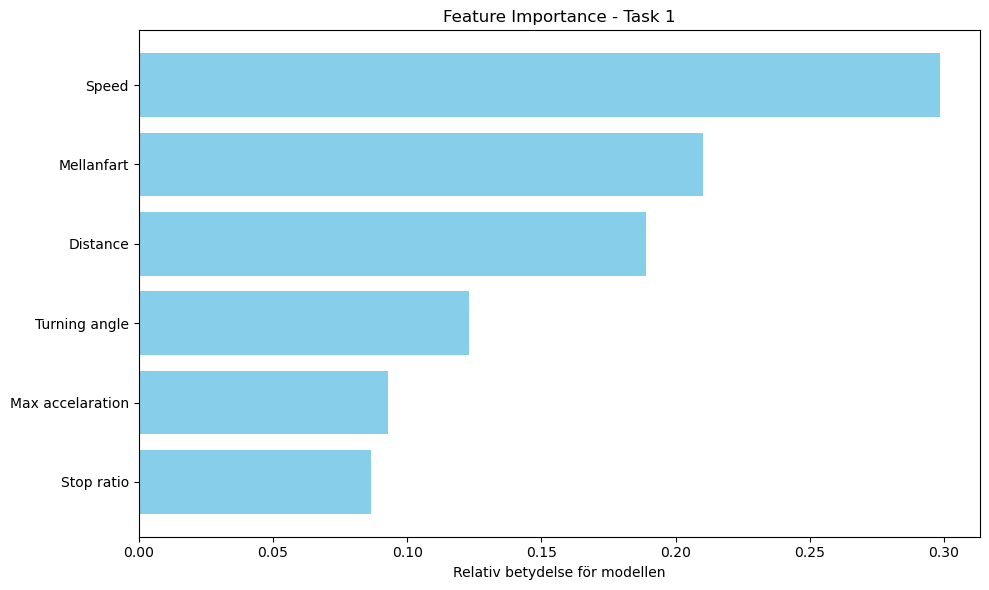

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Splittar features med target, X = fearures och y = target
X = df_final.drop('mode', axis=1)
y = df_final['mode']

# Splittar träningsdata med testdata - 80/20.
# Anävnder stratify för att få samma fördelning mellan träningsdata och testdata. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Tränar Random Forest för att få Feature Importance med random_state för reproducerbarhet
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Generera Feature Importance Plot
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importance - Task 1')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relativ betydelse för modellen')
plt.tight_layout()
plt.show()



Kommentar: Speed hade absolut störst skillnad på modellen, ca 30 %

"Mellanfart" kom efter på dryga 20 % och distans på knappa 20 %.


# Task 2: Models to classify mobility modes #


### Random forest ###

Här har vi redan tränat modellen för att få ut en importance plot. Nu utvärderar vi

              precision    recall  f1-score   support

        bike       0.91      0.80      0.85       372
         bus       0.73      0.66      0.69       460
         car       0.77      0.69      0.73       351
        walk       0.86      0.96      0.91      1083

    accuracy                           0.83      2266
   macro avg       0.82      0.78      0.79      2266
weighted avg       0.83      0.83      0.83      2266

Snabbkommentar: Den är väldigt bra på cykel och gång, lite lägre på buss och bil. Enligt alla mätvärden



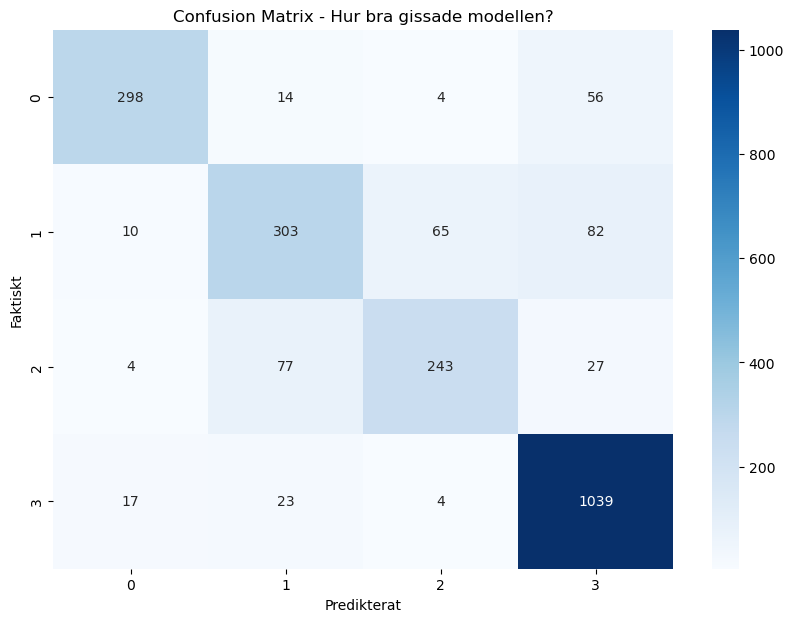

Översättning av targets:
{0: 'bike', 1: 'bus', 2: 'car', 3: 'walk'}

Snabbkommentar: Eftersom walk är överrepresenterat så kanske det hade varit snyggare och enkalre att se med procent i confusion matrixen istället. Tål att tänkas på

              precision    recall  f1-score   support

        bike       0.91      0.81      0.86       372
         bus       0.72      0.65      0.68       460
         car       0.76      0.68      0.72       351
        walk       0.87      0.96      0.91      1083

    accuracy                           0.83      2266
   macro avg       0.81      0.78      0.79      2266
weighted avg       0.83      0.83      0.83      2266

Snabbkommentar: Ingen större skilland. Konstigt nog något sämre på bus och car som den redan var sämst på.
Denna skrotar vi, kanske tom ta bort?



In [8]:
from sklearn.metrics import classification_report, confusion_matrix

# Nu testar vi modellen mot testdata
y_pred = rf_model.predict(X_test)

# Skriv ut en classification rapport.
print(classification_report(y_test, y_pred))
print("Snabbkommentar: Den är väldigt bra på cykel och gång, lite lägre på buss och bil. Enligt alla mätvärden")
print()

# Vi gör en confusion matrix för att visualisera tydligt
cm = confusion_matrix(y_test, y_pred)

# Rita ut den snyggt med Seaborn
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predikterat')
plt.ylabel('Faktiskt')
plt.title('Confusion Matrix - Hur bra gissade modellen?')
plt.show()
print("Översättning av targets:")
print(dict(enumerate(df_features_test['mode'].astype('category').cat.categories)))
print()
print("Snabbkommentar: Eftersom walk är överrepresenterat så kanske det hade varit snyggare och enkalre att se med procent i " \
"confusion matrixen istället. Tål att tänkas på")
print()

# Vi testar att använda class_weight=balanced för att se om det gör skillnad då walk är så överrepresenterad.
# det gör att den lägger mer "weight" åt mindre klasser så de får mer att säga till om. Vilket väger större klassen walk som får mindre "weight"
#Balanserar upp ojämna features helt enkelt
rf_model_weight = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model_weight.fit(X_train, y_train)

# Nu testar vi modellen mot testdata
y_pred_weight = rf_model_weight.predict(X_test)

#Skriv ut en classification rapport.
print(classification_report(y_test, y_pred_weight))
print("Snabbkommentar: Ingen större skilland. Konstigt nog något sämre på bus och car som den redan var sämst på.")
print("Denna skrotar vi, kanske tom ta bort?")
print()





### Deep Learning ###


In [14]:
# Provar en cnn deep learning med npz filen.
# Se vad som finns i filen
print(sequence.files)
# utforkar datan
print("Formen på X_seq:", sequence['X_seq'].shape)
print("Formen på y_seq:", sequence['y_seq'].shape)
print("")
print("Vad ser vi?: 11326 antal segment, 128 gps-punkter per resa, 5 olika särdrag ex hastighet, kursändring osv.")
print("Slutsats: Datafilen är förberedd för deeplearning. Rätt form från början, en 3d matris som behövs.")
print("Så det är bara att använda filen.")

['X_seq', 'y_seq', 'groups', 'segment_id']
Formen på X_seq: (11326, 128, 5)
Formen på y_seq: (11326,)

Vad ser vi?: 11326 antal segment, 128 gps-punkter per resa, 5 olika särdrag ex hastighet, kursändring osv.
Slutsats: Datafilen är förberedd för deeplearning. Rätt form från början, en 3d matris som behövs.
Så det är bara att använda filen.


In [13]:
# CNN Modell
# Baserat på: https://github.com/AmirSarrafzadeh/Transport-Mode-Detection/blob/main/005_CNN_Model.ipynb

import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, Flatten, MaxPooling1D, BatchNormalization, Activation
from tensorflow.keras.optimizers import RMSprop
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sn

# delar upp datan
X_seq = sequence['X_seq'].astype('float32')
y_seq = sequence['y_seq'].reshape(-1, 1)
groups = sequence['groups'] 


